# Analisis Exploratorio de Datos

## 1.- Introducción muuuuy rapida a Data Frames

Puedes pensar en un **dataframe** como una variablesota donde puedes guardar tablas enteras (en vez de números o palabras sencillos).

Los dataframes no son nativos de Python, vienen de una libreria llamada **Pandas**

Lo primero que se necesita para trabajar con susodichos dataframes es... importar Pandas

In [1]:
import pandas as pd

Ok, ahora vamos a crear un Dataframe que almacene todos los datos que vienen en nuestro archivo de Excel CSV

In [2]:
df_train = pd.read_csv("train.csv")

Veamos como se importo nuestra base de datos a df

Ok, veamos códigos útiles para analizar Dataframes. El primer método es **head**

In [3]:
df_train.head(20) # 20 x 81 columns show 20 primeros

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


Ahora conozcamos **shape**

In [4]:
df_train.shape # (1460,81)

(1460, 81)

Que al si quieremos ver una columna en especifico? ponemos el nombre de la columna entre corchetes

In [6]:
df_train["Id"]

0          1
1          2
2          3
3          4
4          5
        ... 
1455    1456
1456    1457
1457    1458
1458    1459
1459    1460
Name: Id, Length: 1460, dtype: int64

Ok, ahora vamos viendo 2 columnas a la vez

In [8]:
df_train[["Id","SalePrice"]]

,Id,SalePrice
0,1,208500
1,2,181500
2,3,223500
3,4,140000
4,5,250000
...,...,...
1455,1456,175000
1456,1457,210000
1457,1458,266500
1458,1459,142125


Por último, vamos pégandole a la estádistica descriptiva. El método **mean** te da los promedios que quieres saber del DF

In [9]:
df_train["SalePrice"].mean() # (180921.19589041095)

np.float64(180921.19589041095)

Y el método **Describe** te da un resumen de todo en el Dataframe

In [10]:
df_train["SalePrice"].describe

<bound method NDFrame.describe of 0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64>

## 2.- Primeros pasos - traer todo lo importante

Importa todas las librerías que vas a necesitar

- pandas como pd
- matplotlib.pyplot como plt
- seaborn como sns
- numpy como np
- scipy.stats traer norm
- sklearn.preprocessing traer standardscaler
- scipy traer stats
- warnings

y %matplotlib inline

In [30]:
import pandas as pd # Manipulacion de datos
import matplotlib.pyplot as plt # graficas
import seaborn as sns # graficas más bonitas
import numpy as np # metodos númericos para python
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings 

%matplotlib inline

Importa el csv de train.csv para poder tener los datos

La idea es identificar cuales columnas creemos que van a tener el mayor impacto sobre el precio de la vivienda. 

Al final veremos que las columnas con mayor impacto son:

Variables de Construcción
- CalidadTotal
- AñoConstruccion

Variables de Espacio
- AreaSotano
- AreaVivienda

## 3.- Analisis de Precio de Ventas

Lo primero es conocer a "PrecioVenta". Vamos viendo su **describe**

In [31]:
df_train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Ahora vamos pidiendole una foto - hagamos una gráfica de **distplot**

Veremos que
- Se desvía de la distribucion normal
- Tiene Skew positivo (oblicuidad)
- Muestra Peakedness (kurtosis??)

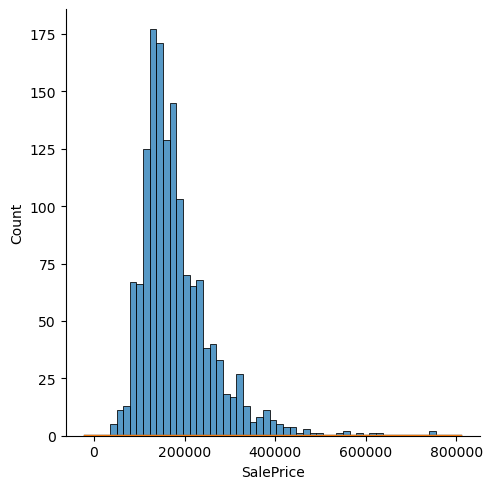

In [33]:
df_train = pd.read_csv('train.csv')
plt.hist(df_train['SalePrice'], density=True, bins=50)
sns.kdeplot(df_train['SalePrice'])
plt.show()

Podemos conocer el skewness y la kurtosis de la gráfica usando los métodos **skew** y **kurt**

In [35]:
df_train["SalePrice"].skew() # 1.8828757597682129

np.float64(1.8828757597682129)

In [36]:
df_train["SalePrice"].kurt() # 6.536281860064529

np.float64(6.536281860064529)

Vamos viendo que sucede con las amigas de "PrecioVenta" - dibujemos un ScatterPlot de PrecioVenta vs AreaVivienda. Nota como vamos a reducir el dataframe a solo 2 columnas para no tener que usar todo

Primero declara una variable var que contenga el area vivible

In [37]:
var = "GrLivArea"

Luego vamos a usar pd.concat para crear una tabla de solo 2 columnas con area vivible (var) y Precio de venta que se llame data

In [38]:
data = pd.concat([df_train["SalePrice"],df_train[var]], axis=1)

In [39]:
data.head(20)

,SalePrice,GrLivArea
0,208500,1710
1,181500,1262
2,223500,1786
3,140000,1717
4,250000,2198
5,143000,1362
6,307000,1694
7,200000,2090
8,129900,1774
9,118000,1077


y ahora vamos a terminar con un data.plot.scatter para crear una grafica de scatterplot. 

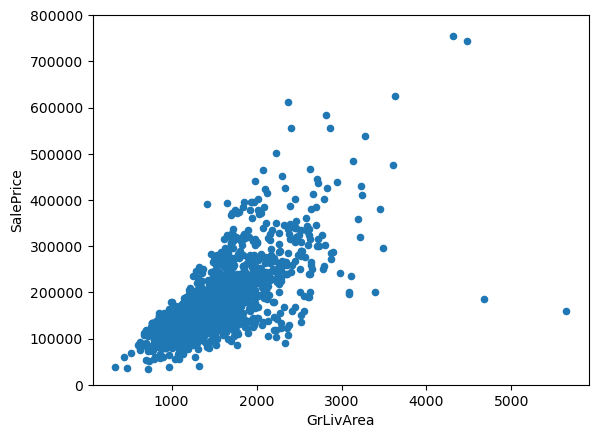

In [43]:
data.plot.scatter(x=var,y="SalePrice",ylim=(0,800000));
plt.show()

Ahora que pasa con "PrecioVenta" y "AreaSotano"? Son amigas pero su relación no es lineal. Sin mencionar que a veces, el AreaSotano se va en su onda y evita el PrecioVenta

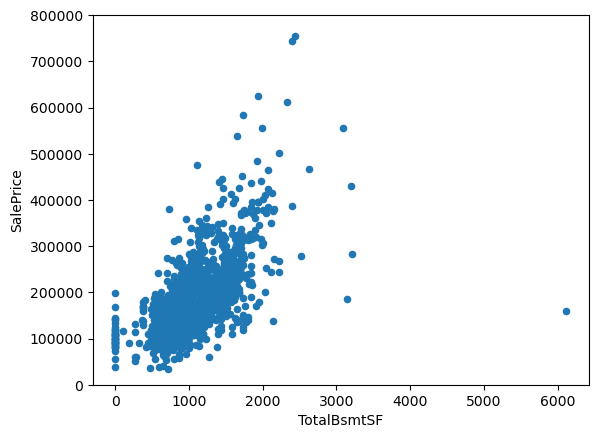

In [47]:
var = "TotalBsmtSF"
data = pd.concat([df_train["SalePrice"],df_train[var]],axis=1)
data.plot.scatter(x=var, y="SalePrice",ylim=(0,800000));
plt.show()

#### Relaciones categóricas

Vamos ahor a armar una gráfica de boxplot para verificar el efecto de la Calidad sobre el precio de ventas. 

Comenzamos igual, declara una variable var = "CalidadTotal"

Y una data donde concatenes el precio de ventas con var

In [96]:
var = "OverallQual"
data = pd.concat([df_train["SalePrice"],df_train[var]], axis=1)
data.head(5)

,SalePrice,OverallQual
0,208500,7
1,181500,6
2,223500,7
3,140000,7
4,250000,8


Ahora viene lo dificl, en dos variables f y ax, vas a guardar el resultado de un plt.subplots - donde se define la nueva figura donde existirá la gráfica que se va a crear. F y ax es la figura y los ejes que devuelve la instruccion

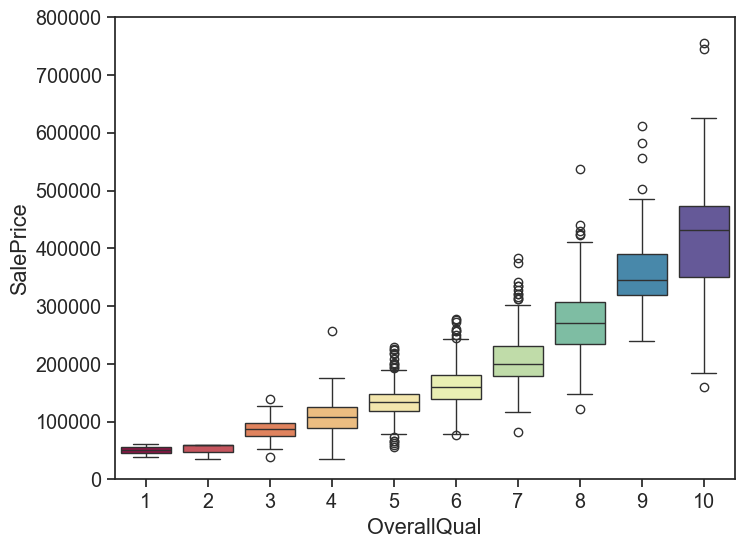

In [97]:

f, ax = plt.subplots(figsize=(8, 6))

# Se añade 'hue=var' y 'legend=False' para cumplir con la nueva sintaxis
sns.boxplot(x=var, y="SalePrice", data=data, ax=ax, hue=var, palette="Spectral", legend=False)

ax.set_ylim(0, 800000)
plt.show()

por ultimo, definimos fig como una variable donde haremos un sns.boxplot (para guardar la grafica)

y definiremos el eje fig.axis de 0 a 8000000

Hagamos lo exacto mismo pero con Precio de Venta vs Año Construida

In [98]:
var = "YearBuilt"
data = pd.concat([df_train["SalePrice"],df_train[var]], axis=1)
data.head()

,SalePrice,YearBuilt
0,208500,2003
1,181500,1976
2,223500,2001
3,140000,1915
4,250000,2000


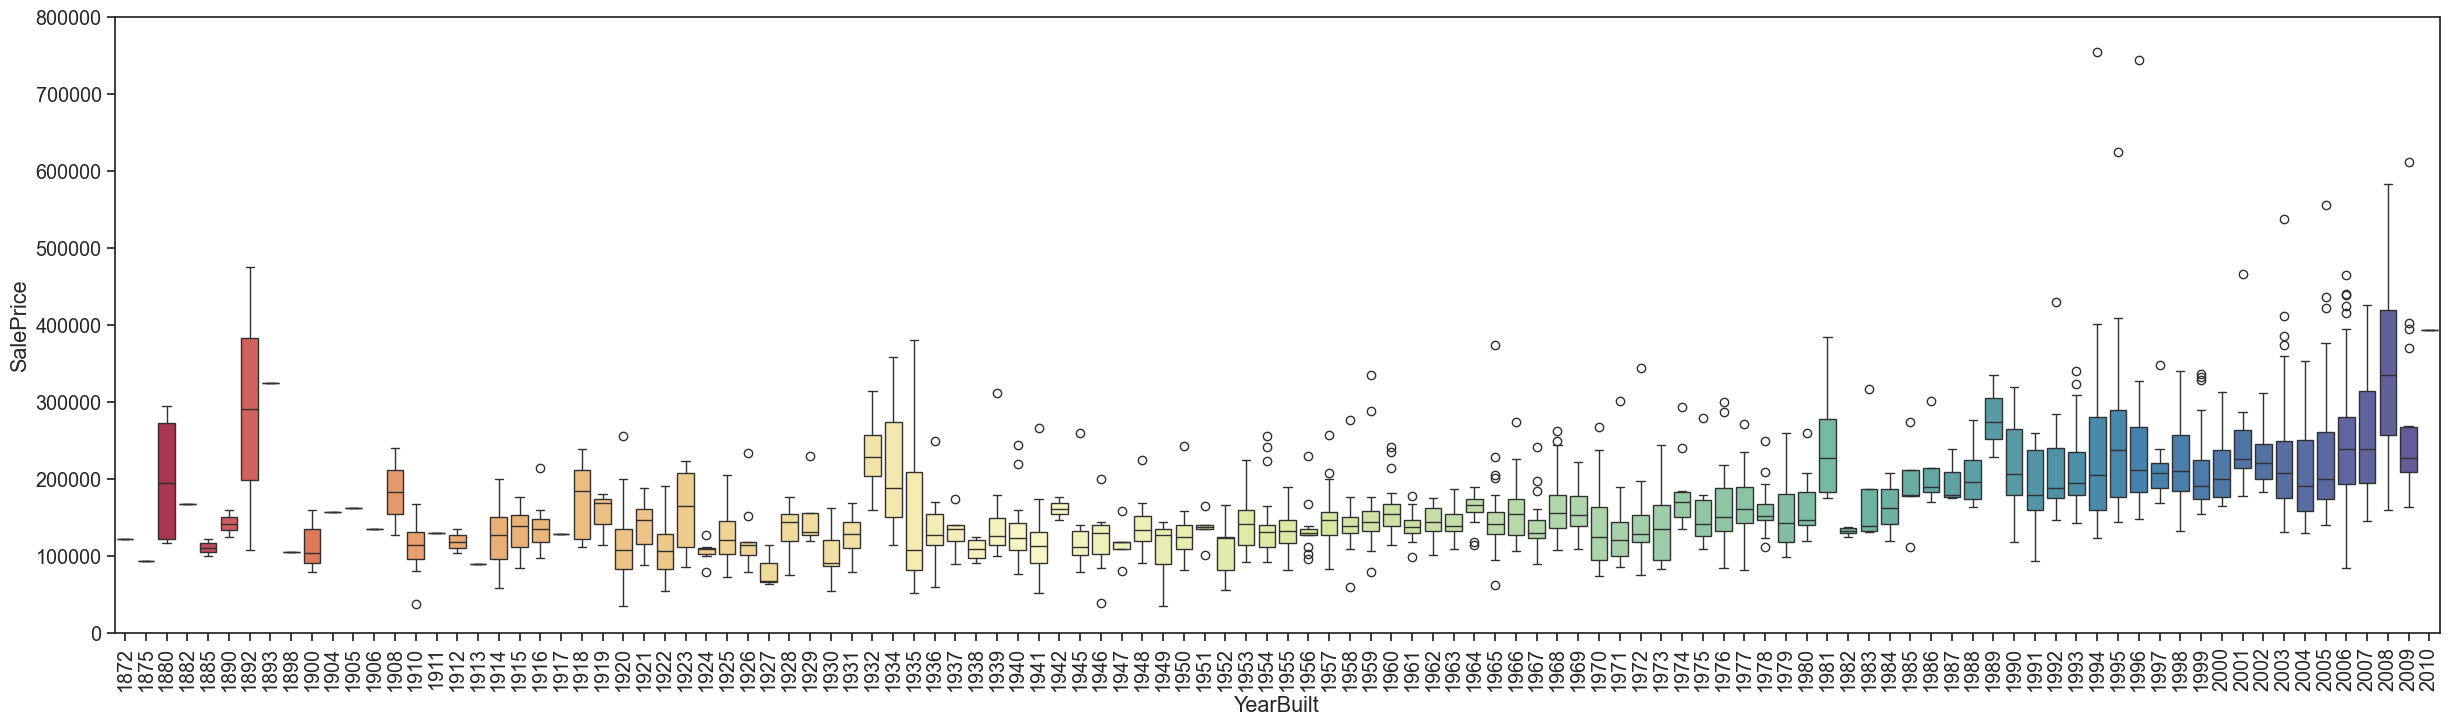

In [99]:
f, ax = plt.subplots(figsize=(30, 8))
sns.boxplot(x=var, y="SalePrice", data=data, ax=ax, hue=var, palette="Spectral", legend=False)
ax.set_ylim(0, 800000)
plt.xticks(rotation=90)
plt.show()

#### En resumen

¿Que es lo que observas de las variables númericas?

¿Que es lo que observas de las variables catégoricas

## 4.- Confirmando nuestra intuición

Hasta ahora decidimos a puro pulso que estas 4 eran las variables importantes, vamos confirmando con números si es verdad o no

### 4.1.- Matriz de Correlación

Lo primero es armar una matriz de correlación (mapa de calor) para ver cuales son las variables más correlacionadas

Vamos declarando una variable corrmat = df_train.corr() con todas las correlaciones entre variables

In [103]:
matriz_correlacion = df_train.corr(numeric_only=True)

Luego unas f,ax para declarar un plt.subplots

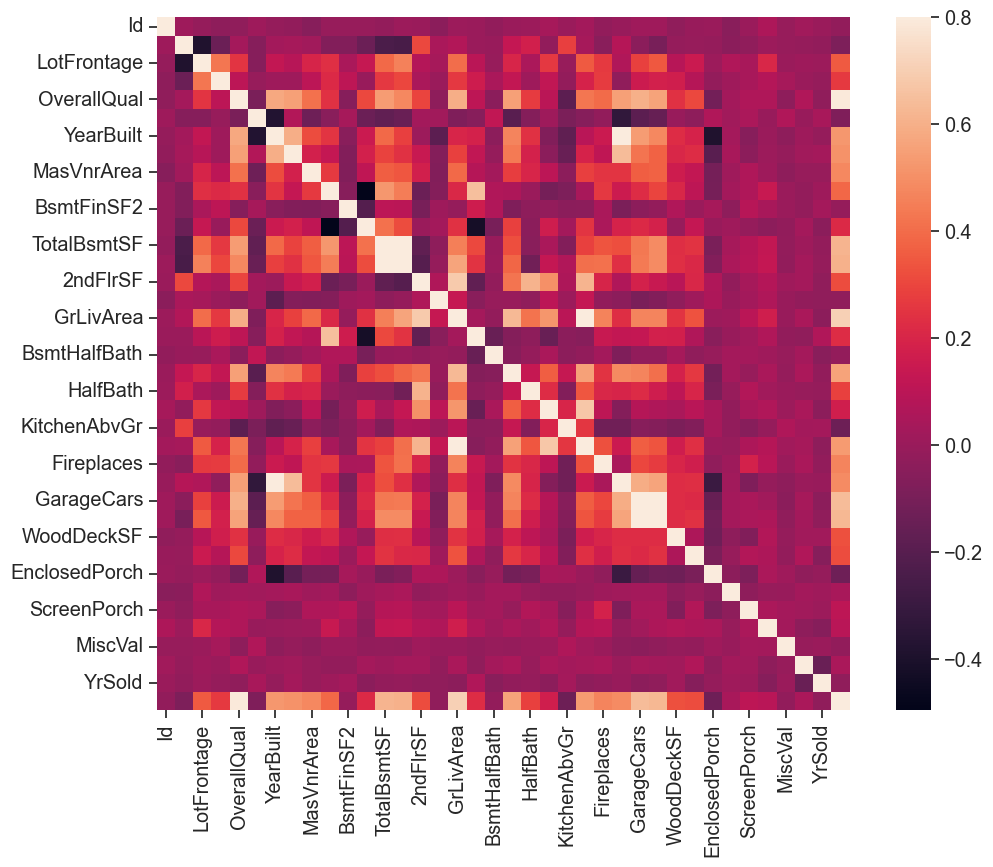

In [108]:
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(matriz_correlacion, vmax=.8,square = True)
plt.show()

Y finalmente hacemos el sns.heatmap

### 4.2.- Matriz de Correlación con Números

Ok, vamos haciendo lo mismo pero ahora con números - y vamos viendo quien se correlaciona más - sin llegar al punto que las 2 variables sean basicamente lo mismo claro

Comenzamos declarando k=10

In [111]:
k = 10

Luego cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].inde

In [112]:
cols = matriz_correlacion.nlargest(k,"SalePrice")["SalePrice"].index

In [113]:
cols

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt'],
      dtype='object')

A continuación vamos a cm = np.corrcoef(df_train[cols].values.T)

In [115]:
cm = np.corrcoef(df_train[cols].values.T)
cm

array([[1.        , 0.7909816 , 0.70862448, 0.6404092 , 0.62343144,
        0.61358055, 0.60585218, 0.56066376, 0.53372316, 0.52289733],
       [0.7909816 , 1.        , 0.59300743, 0.60067072, 0.56202176,
        0.5378085 , 0.47622383, 0.55059971, 0.42745234, 0.57232277],
       [0.70862448, 0.59300743, 1.        , 0.46724742, 0.46899748,
        0.4548682 , 0.56602397, 0.63001165, 0.82548937, 0.19900971],
       [0.6404092 , 0.60067072, 0.46724742, 1.        , 0.88247541,
        0.43458483, 0.43931681, 0.46967204, 0.36228857, 0.53785009],
       [0.62343144, 0.56202176, 0.46899748, 0.88247541, 1.        ,
        0.48666546, 0.48978165, 0.40565621, 0.33782212, 0.47895382],
       [0.61358055, 0.5378085 , 0.4548682 , 0.43458483, 0.48666546,
        1.        , 0.81952998, 0.32372241, 0.28557256, 0.391452  ],
       [0.60585218, 0.47622383, 0.56602397, 0.43931681, 0.48978165,
        0.81952998, 1.        , 0.38063749, 0.40951598, 0.28198586],
       [0.56066376, 0.55059971, 0.6300116

Seguimos con sns.set(font_scale=1.25)

In [117]:
sns.set(font_scale=1.25)

Armarmos el heatmap con hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)

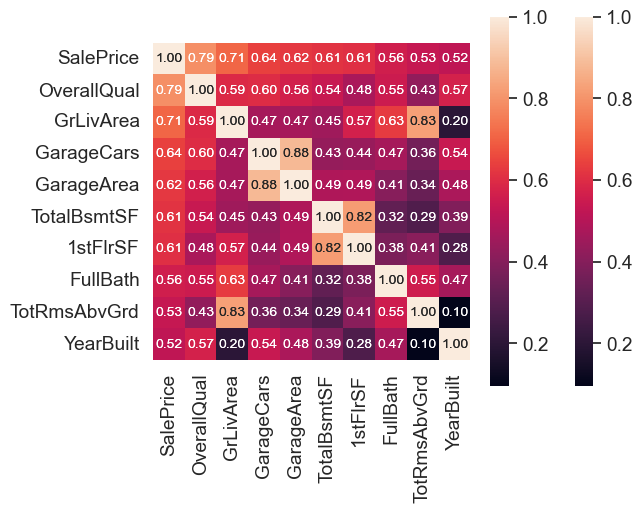

In [121]:
hm = sns.heatmap(cm,cbar=True,annot=True,square = True,fmt='.2f',annot_kws={"size":10},yticklabels=cols.values,xticklabels=cols.values)
plt.show()

Podemos ver que:
- Calidad, AreaVivienda y area Sotano estan muy fuertemente correlacionadas con PrecioVenta
- Las variables de garage están super correlacionadas
- Sotano y 1er piso son basicamente hermanos gemelos
- Y AñoConstruccion esta ligeramente correlacionada con PrecioVenta, parece que en un futuro habra que hacer un analisis de serie de tiempo más serio.

### 4.3.- Scatter Plots entre Sale Price y variables Correlacionados

Por utlimo, hagamos scatterplots usando seabron de todas las posibles relaciones que podríamos tener en nuestro dataset - entre las variables que nos importan claro.

Comenzamos declarando sns.set()

In [122]:
sns.set()

Luego cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']

In [ ]:
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']

Seguimos con sns.pairplot(df_train)

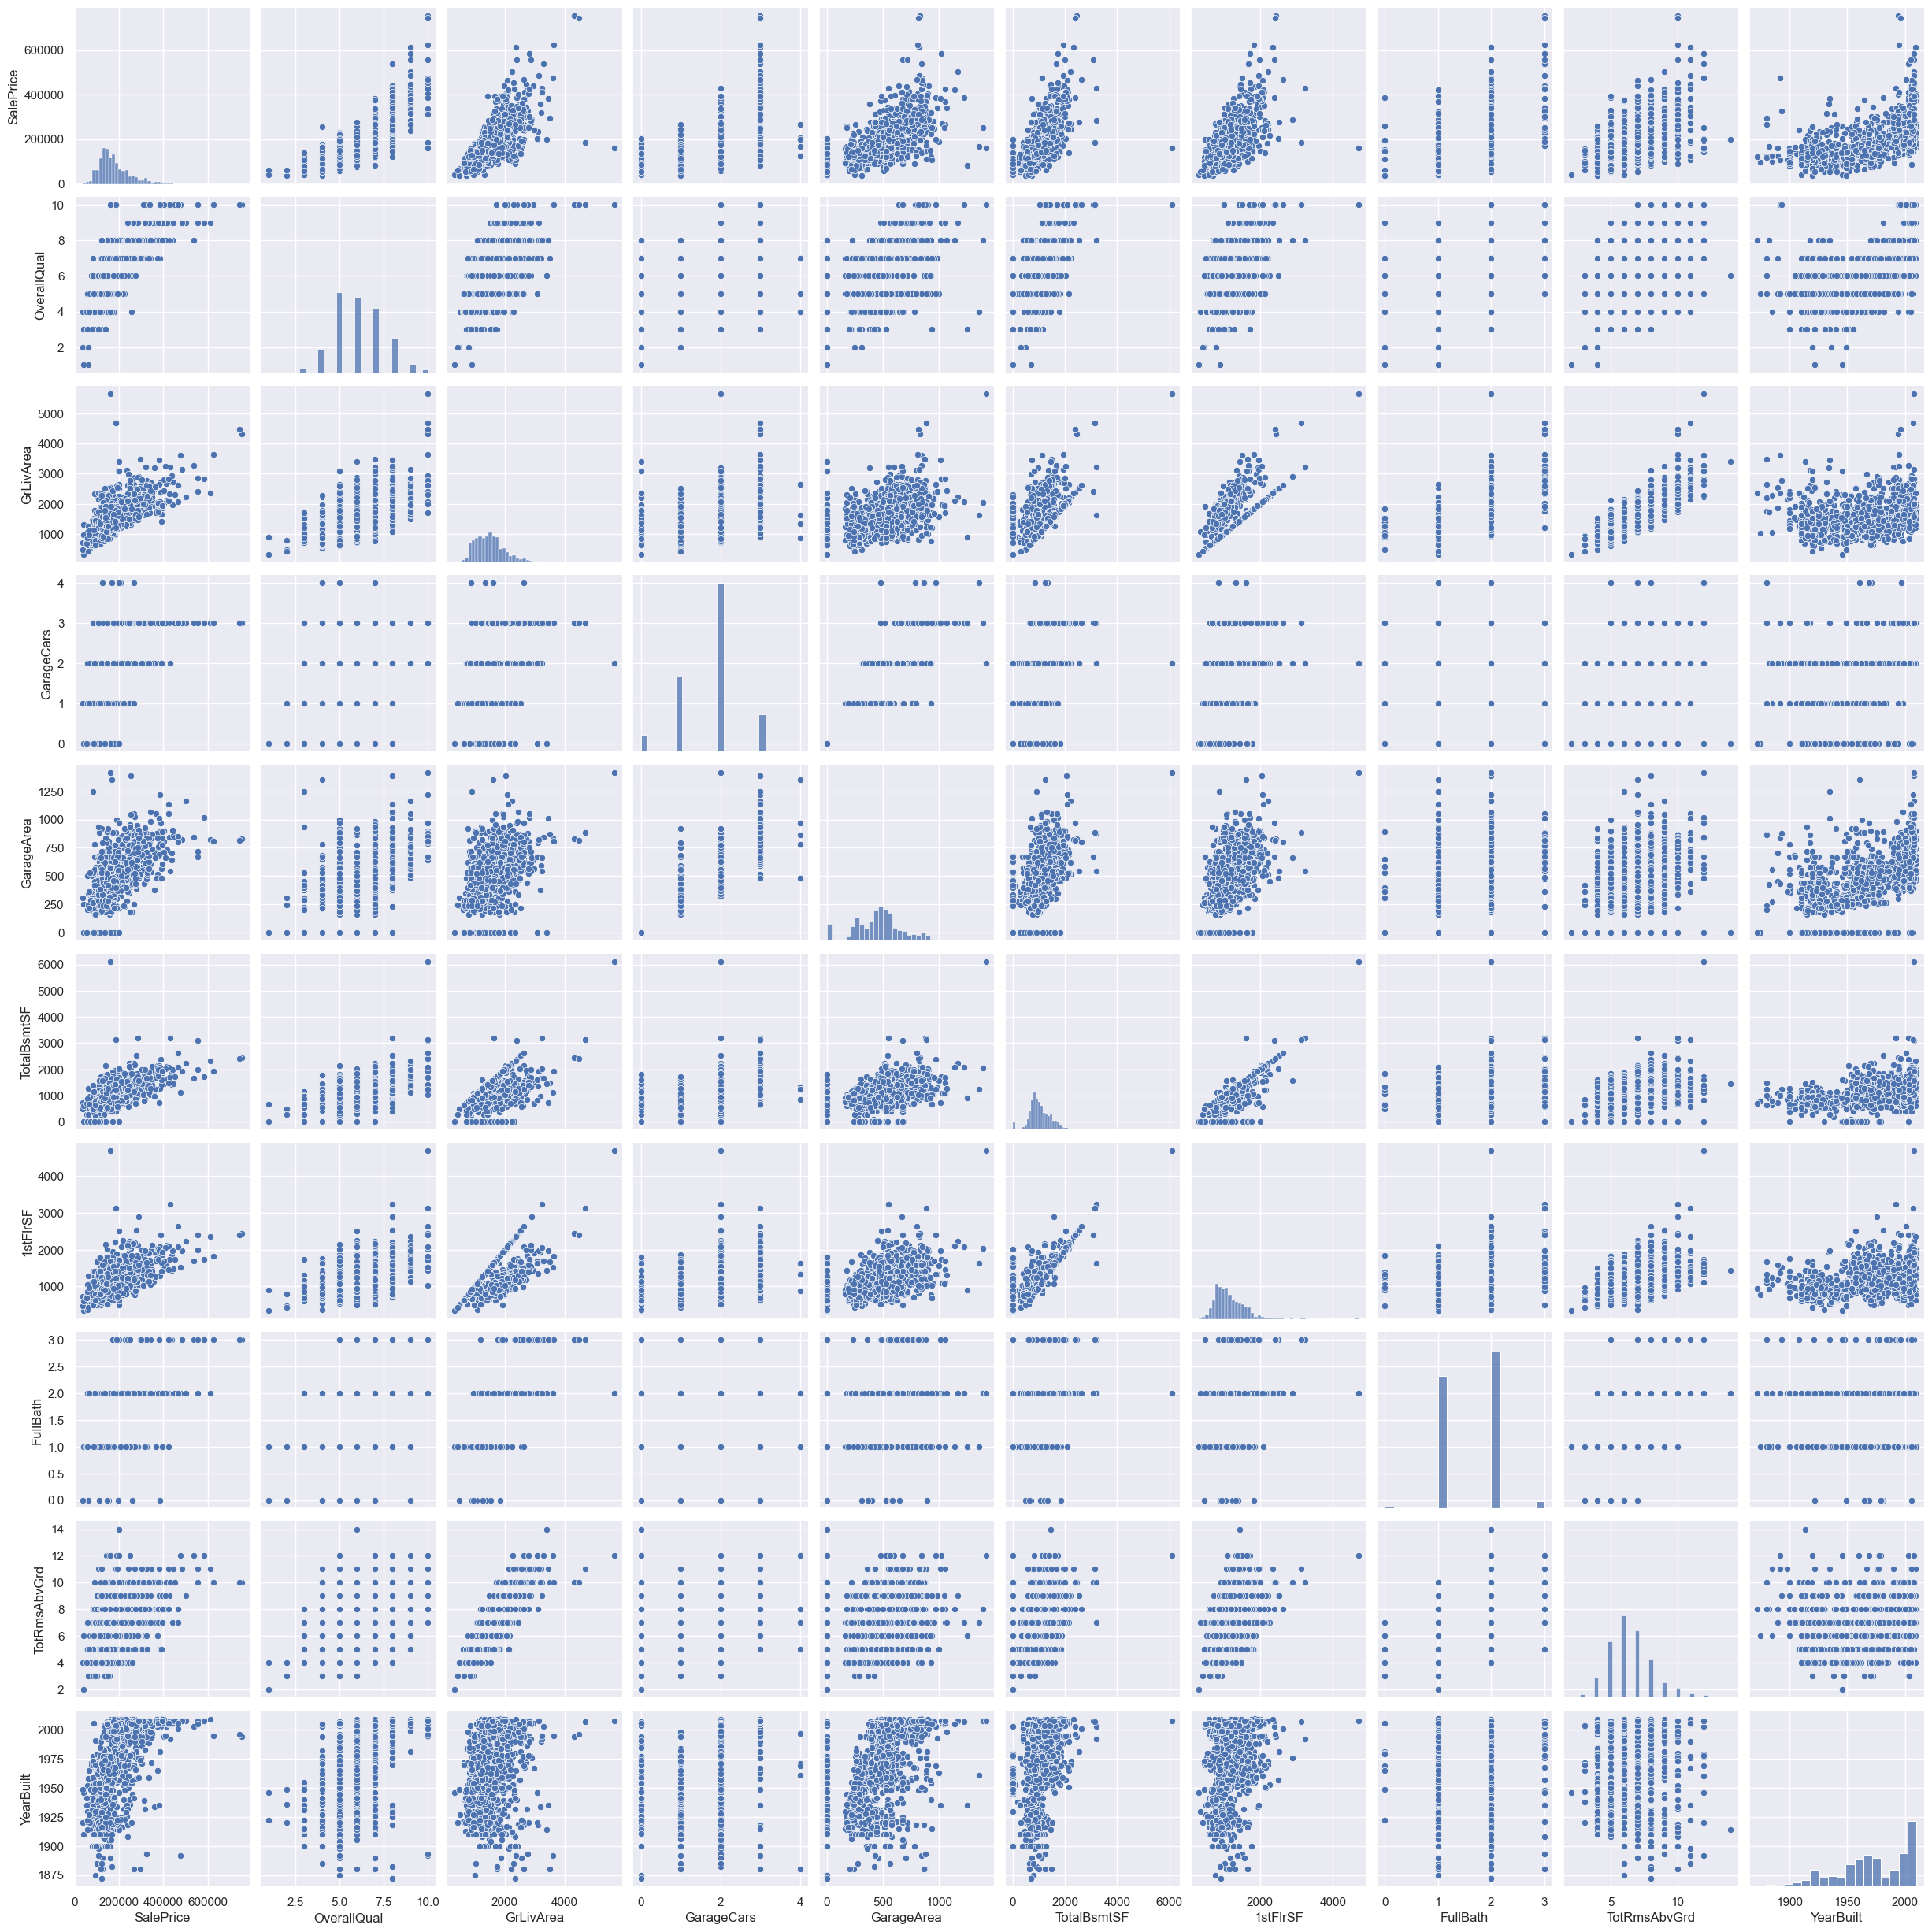

In [124]:
sns.pairplot(df_train[cols],height=2.5)
plt.show()

Y terminamos con plt.show();